# LEAP Data Review

Reviewing data from the LEAP Software. Software available to install on Drive.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
from src.datasources.era5 import fetch_era5_data
from src.datasources.seas5 import fetch_seas5_data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from affine import Affine
from rasterstats import zonal_stats
import calendar

In [3]:
pd.options.display.float_format = "{:,.1f}".format

In [4]:
# reading in population data
eth_adm_pop = stratus.load_csv_from_blob(
    "ds-aa-eth-drought/processed/eth_adm2_pop.csv",
    stage="dev",
    container_name="projects",
)

In [5]:
eth_adm_pop.columns

Index(['fid', 'adm2_id', 'adm2_src', 'adm2_name', 'adm2_name1', 'adm2_name2',
       'adm1_id', 'adm1_src', 'adm1_name', 'adm1_name1', 'adm1_name2',
       'adm0_id', 'adm0_src', 'adm0_name', 'adm0_name1', 'adm0_name2',
       'src_lvl', 'src_lang', 'src_lang1', 'src_lang2', 'src_date',
       'src_update', 'src_name', 'src_name1', 'src_lic', 'src_url', 'src_grp',
       'iso_cd', 'iso_2', 'iso_3', 'iso_3_grp', 'region3_cd', 'region3_nm',
       'region2_cd', 'region2_nm', 'region1_cd', 'region1_nm', 'status_cd',
       'status_nm', 'wld_date', 'wld_update', 'wld_view', 'wld_notes', 'mean',
       'sum'],
      dtype='object')

In [18]:
# looking at the yield reduction
season = "Belg"  # or Belg/Meher
yield_reduction_path = (
    f"ds-aa-eth-drought/exploration/leap/Yield_Reduction_Basket_{season}.csv"
)
yield_reduction = stratus.load_csv_from_blob(
    yield_reduction_path, stage="dev", container_name="projects"
)
adm2_col = yield_reduction.iloc[1:, 1].rename("adm2_name")

# keep only valid year columns
year_cols = [
    c for c in yield_reduction.columns if c.startswith("Basket_Yield_Reduction_")
]

years = [int(c.split("_")[-1]) for c in year_cols]
df = yield_reduction[["ZONENAME"] + year_cols].copy()
df = df.rename(columns={"ZONENAME": "adm2_name"})
df.columns = ["adm2_name"] + years

# ensure numeric
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")
# drop col 1996
df = df.drop(columns=[1996])

df.head()

,adm2_name,2025,2024,2023,2022,2021,2020,2019,2018,2017,...,2006,2005,2004,2003,2002,2001,2000,1999,1998,1997
0,Afder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Agnuak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Alaba Special,13.0,4.0,1.0,54.0,28.0,16.0,9.0,12.0,38.0,...,21.0,21.0,42.0,40.0,46.0,28.0,14.0,49.0,9.0,41.0
3,Amaro Special,0.0,2.0,3.0,52.0,21.0,16.0,35.0,5.0,47.0,...,2.0,10.0,42.0,14.0,34.0,45.0,42.0,31.0,15.0,33.0
4,Arsi,29.0,23.0,6.0,90.0,38.0,7.0,62.0,7.0,42.0,...,24.0,22.0,37.0,42.0,64.0,42.0,53.0,53.0,38.0,36.0


In [19]:
threshold = 50
df_vals = df.drop(columns=["adm2_name"])

zones_affected = (df_vals > threshold).sum(axis=0)
zones_affected = zones_affected.sort_index()

rp4_threshold = zones_affected.quantile(0.75)
rp4_threshold

11.0

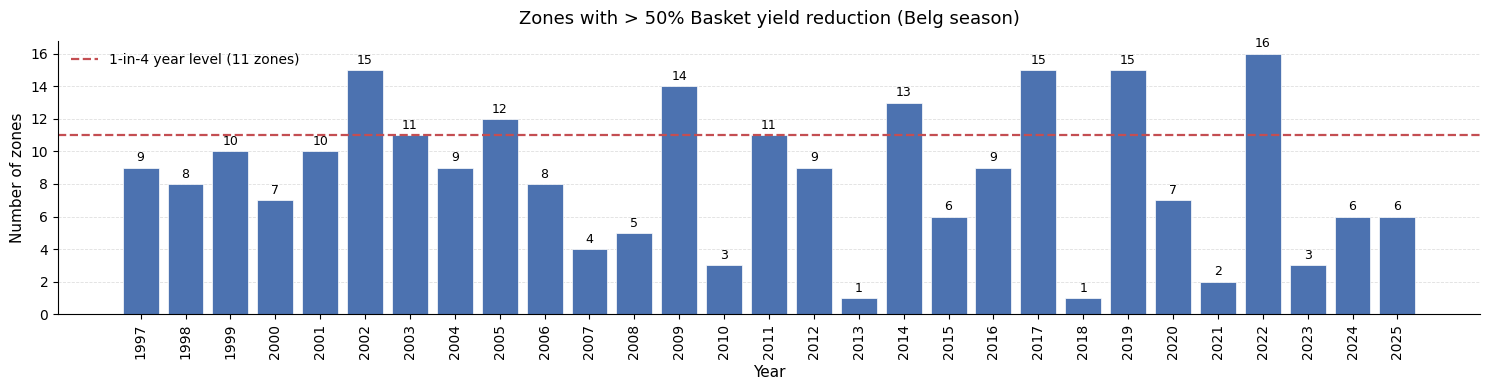

In [20]:
x = range(len(zones_affected))

fig, ax = plt.subplots(figsize=(15, 4))

bars = ax.bar(
    x,
    zones_affected.values,
    width=0.8,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
)

ax.axhline(
    rp4_threshold,
    color="#C44E52",
    linestyle="--",
    linewidth=1.6,
    label=f"1-in-4 year level ({rp4_threshold:.0f} zones)",
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of zones", fontsize=11)
ax.set_title(
    f"Zones with > 50% Basket yield reduction ({season} season)",
    fontsize=13,
    pad=12,
)

# ✅ ticks: positions + labels
ax.set_xticks(x)
ax.set_xticklabels(zones_affected.index, rotation=90)

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

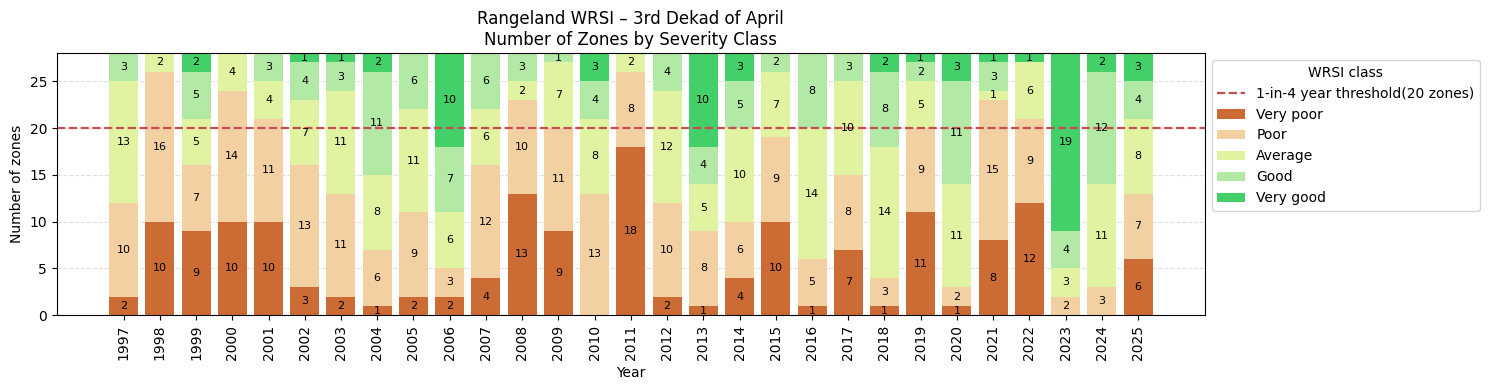

In [23]:
# hindcasts by region
rangeland_wrsi = "ds-aa-eth-drought/exploration/leap/Rangeland WRSI.csv"
wrsi_csv = stratus.load_csv_from_blob(
    rangeland_wrsi, stage="dev", container_name="projects"
)
wrsi_csv = wrsi_csv.dropna(how="all")
wrsi_csv = wrsi_csv.rename(columns={"Name": "region", "Unnamed: 1": "zone"}).dropna(
    subset=["region", "zone"]
)
may_dk3_cols = [c for c in wrsi_csv.columns if c.endswith("_4_3")]
may_dk3 = wrsi_csv[["region", "zone"] + may_dk3_cols]

# long format
may_dk3_long = may_dk3.melt(
    id_vars=["region", "zone"], var_name="year_dekad", value_name="wrsi"
)

# extract year
may_dk3_long["year"] = may_dk3_long["year_dekad"].str.split("_").str[0].astype(int)

# drop missing WRSI
may_dk3_long = may_dk3_long.dropna(subset=["wrsi"])


def classify_wrsi(x):
    if x <= 20:
        return "Very poor"
    elif x <= 40:
        return "Poor"
    elif x <= 60:
        return "Average"
    elif x <= 80:
        return "Good"
    else:
        return "Very good"


may_dk3_long["wrsi_class"] = may_dk3_long["wrsi"].apply(classify_wrsi)
zone_counts = (
    may_dk3_long.groupby(["year", "wrsi_class"])
    .size()
    .reset_index(name="n_zones")
    .sort_values(["year", "wrsi_class"])
)
zones_per_year = may_dk3_long.groupby("year")["zone"].nunique()
class_order = ["Very poor", "Poor", "Average", "Good", "Very good"]
colors = [
    "#cc6c34",
    "#f3d0a2",
    "#e1f3a0",
    "#b1e9a5",
    "#44d069",
]
zone_counts_wide = (
    zone_counts.assign(
        wrsi_class=lambda d: pd.Categorical(d["wrsi_class"], class_order)
    )
    .pivot(index="year", columns="wrsi_class", values="n_zones")
    .fillna(0)
    .sort_index()
)
# total poor + very poor zones per year
poor_vpoor = zone_counts_wide[["Very poor", "Poor"]].sum(axis=1)

# 1-in-4 year threshold (75th percentile)
threshold_1in4 = poor_vpoor.quantile(0.75)

threshold_1in4

fig, ax = plt.subplots(figsize=(15, 4))

bottom = np.zeros(len(zone_counts_wide))
x = zone_counts_wide.index

for cls, col in zip(class_order, colors):
    vals = zone_counts_wide[cls].values
    ax.bar(x, vals, bottom=bottom, label=cls, width=0.8, color=col)
    for x_i, v, b in zip(zone_counts_wide.index, vals, bottom):
        if v > 0:
            ax.text(
                x_i,
                b + v / 2,
                f"{int(v)}",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )
    bottom = vals if bottom is None else bottom + vals
ax.axhline(
    threshold_1in4,
    color="#C44E52",
    linestyle="--",
    linewidth=1.6,
    label=f"1-in-4 year threshold({threshold_1in4:.0f} zones)",
)
ax.set_title("Rangeland WRSI – 3rd Dekad of April\nNumber of Zones by Severity Class")
ax.set_xlabel("Year")
ax.set_ylabel("Number of zones")

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(
    ncol=1,
    title="WRSI class",
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(1, 1),
)

ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90)

plt.tight_layout()
plt.show()

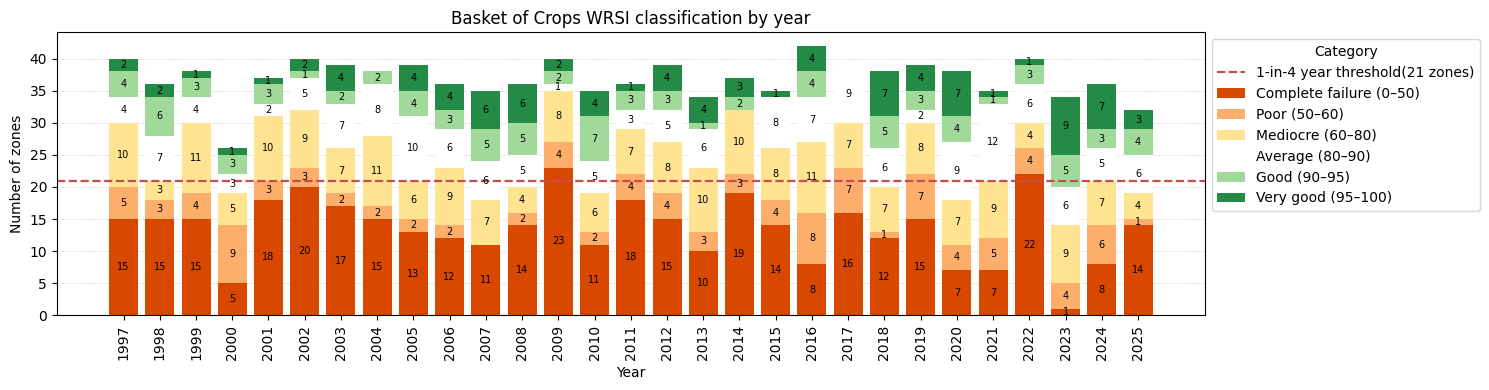

In [24]:
# hindcasts by region
belg_wrsi = "ds-aa-eth-drought/exploration/leap/Final_Index_Basket_Belg.csv"
df = stratus.load_csv_from_blob(belg_wrsi, stage="dev", container_name="projects")
# --- Extract years from first row ---
years = df.iloc[0, 2:].astype(int).values

# --- Drop header row and rename columns ---
data = df.iloc[1:].copy()
data.columns = ["region", "zone"] + list(years)

# --- Melt to long format ---
long_df = data.melt(
    id_vars=["region", "zone"], var_name="year", value_name="index_value"
)

# Ensure numeric
long_df["index_value"] = pd.to_numeric(long_df["index_value"], errors="coerce")

# --- Define categories ---
bins = [0, 50, 60, 80, 90, 95, 100]
labels = [
    "Complete failure (0–50)",
    "Poor (50–60)",
    "Mediocre (60–80)",
    "Average (80–90)",
    "Good (90–95)",
    "Very good (95–100)",
]

long_df["category"] = pd.cut(
    long_df["index_value"], bins=bins, labels=labels, right=True, include_lowest=True
)

# --- Count zones per year per category ---
counts = (
    long_df.groupby(["year", "category"], observed=False)
    .size()
    .reset_index(name="n_zones")
)

counts_wide = (
    counts.pivot(index="year", columns="category", values="n_zones")
    .fillna(0)
    .astype(int)
)

colors = [
    "#d94801",  # complete failure
    "#fdae6b",  # poor
    "#fee391",  # mediocre
    "#ffffff",  # average
    "#a1d99b",  # good
    "#238b45",  # very good
]

# Ensure correct column order
counts_wide = counts_wide[labels]
# total poor + very poor zones per year
poor_vpoor = counts_wide[["Complete failure (0–50)", "Poor (50–60)"]].sum(axis=1)

# 1-in-4 year threshold (75th percentile)
threshold_1in4 = poor_vpoor.quantile(0.75)

threshold_1in4
# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 4))

bottom = None
x = counts_wide.index

for cls, col in zip(labels, colors):
    vals = counts_wide[cls].values
    ax.bar(x, vals, bottom=bottom, color=col, width=0.8, label=cls)

    # add numbers inside bars
    for x_i, v, b in zip(x, vals, bottom if bottom is not None else [0] * len(vals)):
        if v > 0:
            ax.text(
                x_i,
                b + v / 2,
                f"{int(v)}",
                ha="center",
                va="center",
                fontsize=7,
                color="black",
            )

    bottom = vals if bottom is None else bottom + vals
ax.axhline(
    threshold_1in4,
    color="#C44E52",
    linestyle="--",
    linewidth=1.6,
    label=f"1-in-4 year threshold({threshold_1in4:.0f} zones)",
)
# --- Styling ---
ax.set_xlabel("Year")
ax.set_ylabel("Number of zones")
ax.set_title("Basket of Crops WRSI classification by year")

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)

# legend outside
ax.legend(
    title="Category",
    bbox_to_anchor=(1, 1),
    loc="upper left",
)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90)
plt.tight_layout()
plt.show()